In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_input = r"21_05_2026\prueba_08_sinc"

# Leer CSV
df = pd.read_csv(csv_input+".csv")

# Convertir Unix ms a tiempo GMT / UTC
df["timestamp_gmt"] = pd.to_datetime(df["time(ms)"], unit="ms", utc=True)

# Convertir VSS a número
# Los "-" se convierten en NaN
df["VSS(km/h)"] = pd.to_numeric(df["VSS(km/h)"], errors="coerce")

# Opcional: eliminar filas sin velocidad válida
df = df.dropna(subset=["VSS(km/h)"])

# Tiempo relativo en segundos desde el inicio
df["t_s"] = (df["timestamp_gmt"] - df["timestamp_gmt"].iloc[0]).dt.total_seconds()

print(df.head())

        time(ms)  VPWR(V)  VSS(km/h)                    timestamp_gmt    t_s
1  1779393657011    13.47        0.0 2026-05-21 20:00:57.011000+00:00  0.000
2  1779393657026    13.46        0.0 2026-05-21 20:00:57.026000+00:00  0.015
3  1779393657044    13.46        0.0 2026-05-21 20:00:57.044000+00:00  0.033
4  1779393657067    13.46        0.0 2026-05-21 20:00:57.067000+00:00  0.056
5  1779393657075    13.47        0.0 2026-05-21 20:00:57.075000+00:00  0.064


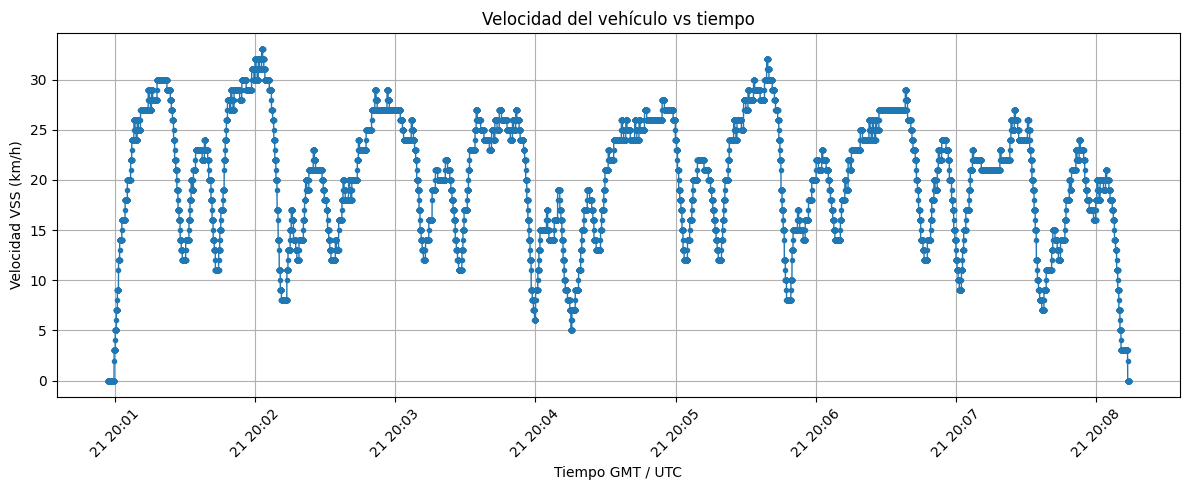

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(df["timestamp_gmt"], df["VSS(km/h)"], marker=".", linewidth=1)

plt.xlabel("Tiempo GMT / UTC")
plt.ylabel("Velocidad VSS (km/h)")
plt.title("Velocidad del vehículo vs tiempo")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
df.to_csv(csv_input+"_out.csv", index=False)